# Problem Statement
Predict the teaching performance of a Teaching Assistant using information such as English proficiency, instructor, course, semester, and class size.

1. Import Libraries

In [89]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report

2. Load Dataset

In [45]:
column_names = [
    "NativeEnglishSpeaker",
    "CourseInstructor",
    "Course",
    "Semester",
    "Class_Size",
    "Performance"
]


df = pd.read_csv("tae.csv", header = None, names = column_names)
df

,NativeEnglishSpeaker,CourseInstructor,Course,Semester,Class_Size,Performance
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3
...,...,...,...,...,...,...
146,2,3,2,2,26,1
147,2,10,3,2,12,1
148,1,18,7,2,48,1
149,2,22,1,2,51,1


In [46]:
df.head()

,NativeEnglishSpeaker,CourseInstructor,Course,Semester,Class_Size,Performance
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3


In [47]:
df.tail()

,NativeEnglishSpeaker,CourseInstructor,Course,Semester,Class_Size,Performance
146,2,3,2,2,26,1
147,2,10,3,2,12,1
148,1,18,7,2,48,1
149,2,22,1,2,51,1
150,2,2,10,2,27,1


In [48]:
df.shape

(151, 6)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   NativeEnglishSpeaker  151 non-null    int64
 1   CourseInstructor      151 non-null    int64
 2   Course                151 non-null    int64
 3   Semester              151 non-null    int64
 4   Class_Size            151 non-null    int64
 5   Performance           151 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


In [50]:
df.describe()

,NativeEnglishSpeaker,CourseInstructor,Course,Semester,Class_Size,Performance
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,1.807947,13.642384,8.105960,1.847682,27.867550,2.019868
std,0.395225,6.825779,7.023914,0.360525,12.893758,0.820327
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,8.000000,3.000000,2.000000,19.000000,1.000000
50%,2.000000,13.000000,4.000000,2.000000,27.000000,2.000000
75%,2.000000,20.000000,15.000000,2.000000,37.000000,3.000000
max,2.000000,25.000000,26.000000,2.000000,66.000000,3.000000


In [51]:
df.columns

Index(['NativeEnglishSpeaker', 'CourseInstructor', 'Course', 'Semester',
       'Class_Size', 'Performance'],
      dtype='object')

In [52]:
df.isnull().sum()

NativeEnglishSpeaker    0
CourseInstructor        0
Course                  0
Semester                0
Class_Size              0
Performance             0
dtype: int64

3. EDA (Exploratory Data Analysis)

In [61]:
df.groupby("Performance")["Class_Size"].mean()

Performance
1    29.428571
2    25.940000
3    28.250000
Name: Class_Size, dtype: float64

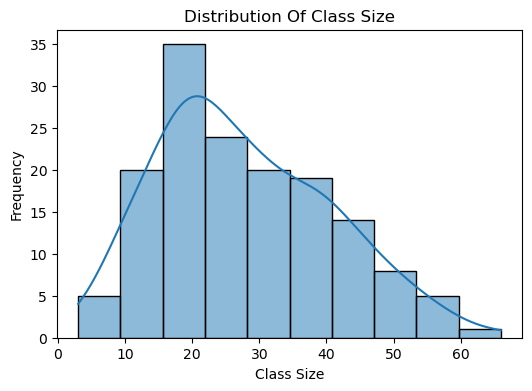

In [53]:
plt.figure(figsize = (6, 4))
sns.histplot(df["Class_Size"], bins = 10, kde = True)
plt.title("Distribution Of Class Size")
plt.xlabel("Class Size")
plt.ylabel("Frequency")
plt.show()

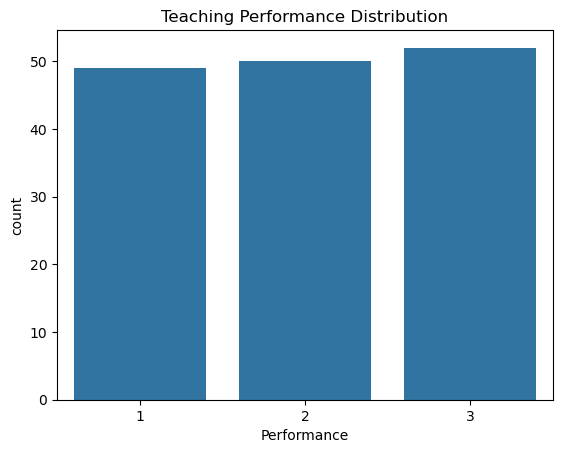

In [54]:
sns.countplot(x = "Performance", data = df)
plt.title("Teaching Performance Distribution")
plt.show()

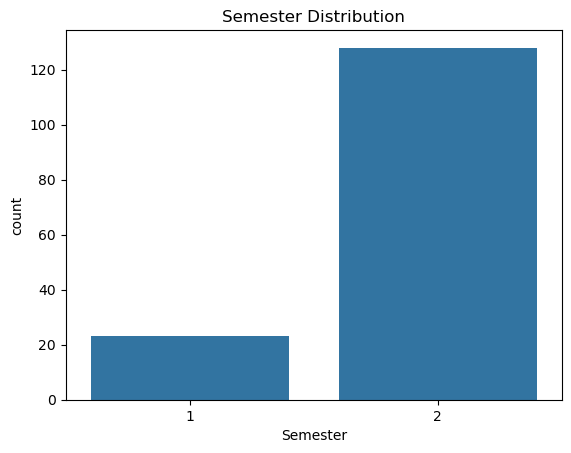

In [55]:
sns.countplot(x = "Semester", data = df)
plt.title("Semester Distribution")
plt.show()

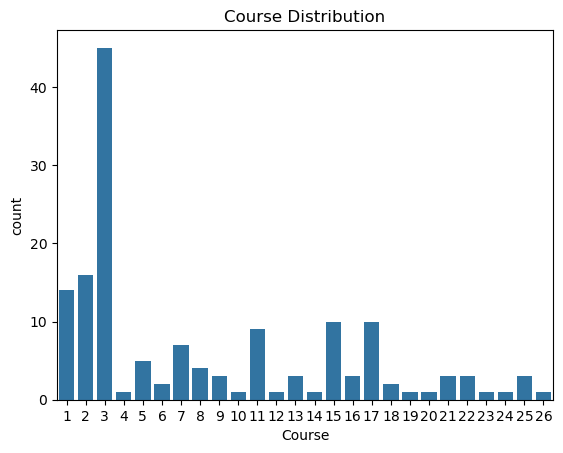

In [56]:
sns.countplot(x = "Course", data = df)
plt.title("Course Distribution")
plt.show()

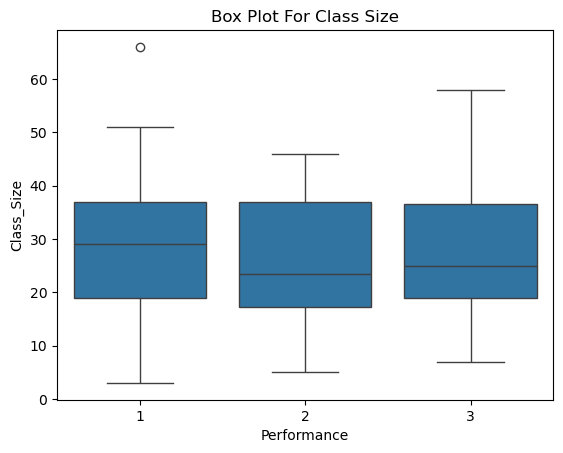

In [64]:
sns.boxplot(x = "Performance", y = "Class_Size", data = df)
plt.title("Box Plot For Class Size")
plt.show()

4. Splitting The Data

In [65]:
X = df.drop("Performance", axis = 1)
y = df["Performance"]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)
print("X train shape", X_train.shape)
print("X test shape", X_test.shape)
print("y train shape", y_train.shape)
print("y test shape", y_test.shape)

X train shape (120, 5)
X test shape (31, 5)
y train shape (120,)
y test shape (31,)


5. Logistic Regression Model

In [77]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

[1 3 3 1 1 1 3 2 2 3 1 2 2 3 2 1 1 1 1 2 1 3 1 2 2 2 2 1 1 1 1]


In [78]:
print("Accuracy Score", accuracy_score(y_test, y_pred))

Accuracy Score 0.5806451612903226


In [84]:
print("Recall Score", recall_score(y_test, y_pred, average = "weighted"))

Recall Score 0.5806451612903226


In [86]:
print("Precision Score", precision_score(y_test, y_pred, average = "weighted"))

Precision Score 0.6086021505376344


In [87]:
print("Confusion Matrix", confusion_matrix(y_test, y_pred))

Confusion Matrix [[8 3 0]
 [5 5 1]
 [2 2 5]]


In [88]:
print("Classification Report", classification_report(y_test, y_pred))

Classification Report               precision    recall  f1-score   support

           1       0.53      0.73      0.62        11
           2       0.50      0.45      0.48        11
           3       0.83      0.56      0.67         9

    accuracy                           0.58        31
   macro avg       0.62      0.58      0.59        31
weighted avg       0.61      0.58      0.58        31



6. Random Forest Model

In [90]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

[1 2 2 1 1 1 3 2 2 2 3 3 1 3 2 1 1 1 2 3 1 3 2 3 2 3 1 1 1 1 2]


In [91]:
print("Accuracy Score", accuracy_score(y_test, y_pred))

Accuracy Score 0.7096774193548387


In [93]:
print("Recall Score", recall_score(y_test, y_pred, average = "weighted"))

Recall Score 0.7096774193548387


In [94]:
print("Precision Score", precision_score(y_test, y_pred, average = "weighted"))

Precision Score 0.7027915632754342


In [95]:
print("Confusion Matrix", confusion_matrix(y_test, y_pred))

Confusion Matrix [[10  0  1]
 [ 2  7  2]
 [ 1  3  5]]


In [96]:
print("Classification Report", classification_report(y_test, y_pred))

Classification Report               precision    recall  f1-score   support

           1       0.77      0.91      0.83        11
           2       0.70      0.64      0.67        11
           3       0.62      0.56      0.59         9

    accuracy                           0.71        31
   macro avg       0.70      0.70      0.70        31
weighted avg       0.70      0.71      0.70        31

